# MCSR Ranked Playoff Prediction
**DADS 7275 — Final Project**

**Objective:** Use historical ranked match data (Seasons 1–9) to predict Season 10 MCSR Ranked playoff tournament outcomes.

**Models:** K-Means Clustering · Logistic Regression · LDA · Monte Carlo Simulation

**Data:** ~11,000 ranked matches from the MCSR Ranked API across 9 competitive seasons


In [2]:
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

from collections import defaultdict

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import silhouette_score

import plotly.graph_objects as go
import plotly.express as px
from ipywidgets import interact
from ipywidgets import IntSlider
from ipywidgets import Dropdown
from ipywidgets import interactive
import ipywidgets as widgets

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120


In [3]:
BASE_DIR = os.path.abspath('.')           # Root of the project directory
RAW      = os.path.join(BASE_DIR, 'data', 'raw')       # Raw JSON data files
OUT_DIR  = os.path.join(BASE_DIR, 'data', 'processed') # Processed output
os.makedirs(OUT_DIR, exist_ok=True)        # Create output folder if it doesn't exist

SEASONS = list(range(1, 10))  # Season numbers 1 through 9

# Players who qualified for each season's playoff bracket
PLAYOFF_PLAYERS = {
    1: ['silverrruns','dandannyboy','Oxidiot','Reignex','priffie','orachi_','lowk3y_','7rowl','doogile','Ancoboyy','pulsar32','Ranik_','MoleyG','CroProYT','AutomattPL','Dylqn'],
    2: ['lowk3y_','CroProYT','dandannyboy','doogile','7rowl','kW1st','priffie','dwoh','silverrruns','Emillk','bing_pigs','drx6','Ancoboyy','Ranik_','Oxidiot','AutomattPL'],
    3: ['7rowl','Ancoboyy','dandannyboy','doogile','hackingnoises','lowk3y_','Oxidiot','priffie','ANJOUU','AutomattPL','BeefSalad','Bloonskiller','loodlow','paplerr','v_strid','autoqualler'],
    4: ['7rowl','Ancoboyy','dandannyboy','doogile','AutomattPLUS','hackingnoises','Hinart','lowk3y_','Oxidot','paplerr','priffie','silverrruns','ANJOUU','bing_pigs','Cube1337x','v_strid'],
    5: ['7rowl','Ancoboyy','BeefSalad','bing_pigs','doogile','AutomattPLUS','hackingnoises','lowk3y_','Oxidiot','silverrruns','TUDORULE','v_strid','Aquacorde','dandannyboy','KenanKardes','pulsar32'],
    6: ['7rowl','Ayreliaa','BeefSalad','bing_pigs','doogile','AutomattPLUS','Feinberg','hackingnoises','lowk3y_','MrBudgiee','Oxidiot','silverrruns','dandannyboy','Erikfzf','ogurikappa','TUDORULE'],
    7: ['7rowl','Ancoboyy','Aquacorde','BadGamer','BeefSalad','bing_pigs','doogile','Feinberg','Infume','lowk3y_','priffie','retropog','r7sD4fH6jK0wY5uB','hackingnoises','Oxidiot','silverrruns'],
    8: ['7rowl','Aquacorde','BeefSalad','bing_pigs','DARVY__X1','doogile','edcr','Feinberg','Infume','lowk3y_','Ranik_','silverrruns','hackingnoises','KenanKardes','TUDORULE','v_strid'],
    9: ['Feinberg','Infume','edcr','steez','hackingnoises','Aquacorde','nhb_','silverrruns','Pinne','BeefSalad','nahhann','lowk3y_','doogile','HDMICables','bing_pigs','BlazeMind'],
}

# Confirmed Season 10 roster
S10_POOL = {
    'Infume','edcr','doogile','Feinberg','7rowl','bing_pigs',
    'nahhann','BlazeMind','Aquacorde','silverrruns','BeefSalad',
    'meebie','hackingnoises','steez','nhb_','Ancoboyy',
}

TIER_ORDER     = ['champion', 'finalist', 'top4', 'qf_exit', 'r1_exit']  # Best to worst
SEASON_WEIGHTS = {1:1, 2:1, 3:1, 4:2, 5:2, 6:3, 7:4, 8:6}              # Recency weighting

# Names for the 14-feature matchup difference vector
FEATURE_NAMES = [
    'Elo diff', 'WinRate diff', 'RecentWR diff', 'Consistency diff',
    'AvgTime diff (s)', 'DeepRun diff', 'Champion diff', 'Finalist diff',
    'BestTime diff (s)', 'ForfeitRate diff', 'EloMomentum diff',
    'LCQ Flag diff', 'Tournament Delta diff', 'H2H WinRate',
]

print(f'RAW data directory : {RAW}')
print(f'Output directory   : {OUT_DIR}')


RAW data directory : c:\Users\Soi\comp sci\DADS7275\final project\data\raw
Output directory   : c:\Users\Soi\comp sci\DADS7275\final project\data\processed


---
## 1. Data Loading

Raw data is stored as per-season JSON files scraped from the MCSR Ranked API.
Three separate loaders handle different data types:

- `load_all_matches()` — flattens all match records into a single DataFrame
- `load_playoff_results()` — loads confirmed bracket outcomes for each season
- `load_h2h_csv()` — loads aggregated head-to-head win rates from the stats CSV

Each match record contains both players, their pre-match Elo ratings, the winner, and finish time.


In [4]:
# Function to load all match records into a flat DataFrame
def load_all_matches():
    frames = []  # List to accumulate match rows across all seasons

    # Loop through each season and load the corresponding JSON file
    for s in SEASONS:
        fpath = os.path.join(RAW, f'season_{s}_matches.json')  # Path to season file
        if not os.path.exists(fpath):  # Skip if file doesn't exist
            continue
        with open(fpath) as f:
            matches = json.load(f)  # Load the list of match objects

        # Extract fields from each match record
        for m in matches:
            players     = m.get('players', [])           # List of two player objects
            result      = m.get('result') or {}          # Match result (winner UUID + time)
            winner_uuid = result.get('uuid')             # UUID of the winning player
            win_time    = result.get('time')             # Finish time in milliseconds
            forfeited   = m.get('forfeited', False)      # Whether the match was forfeited
            if len(players) < 2:  # Skip incomplete match records
                continue
            p1, p2 = players[0], players[1]  # Split into player 1 and player 2
            frames.append({
                'match_id':    m.get('id'),
                'season':      m.get('season', s),
                'date':        m.get('date'),
                'p1_nick':     p1.get('nickname'),    # Player 1 username
                'p1_uuid':     p1.get('uuid'),        # Player 1 unique ID
                'p1_elo':      p1.get('eloRate'),     # Player 1 Elo before match
                'p2_nick':     p2.get('nickname'),    # Player 2 username
                'p2_uuid':     p2.get('uuid'),        # Player 2 unique ID
                'p2_elo':      p2.get('eloRate'),     # Player 2 Elo before match
                'winner_uuid': winner_uuid,
                'win_time_ms': win_time,
                'forfeited':   forfeited,
            })

    df = pd.DataFrame(frames).drop_duplicates('match_id')  # Remove duplicate match IDs
    df['p1_won'] = df['winner_uuid'] == df['p1_uuid']       # True if player 1 won
    return df


# Function to load confirmed playoff bracket results for each season
def load_playoff_results():
    path = os.path.join(RAW, 'all_playoff_results.json')  # Path to results file
    with open(path) as f:
        results = {int(k): v for k, v in json.load(f).items()}  # Parse season keys as ints

    # Override with confirmed Season 9 ground truth
    results[9] = {
        'champion': 'hackingnoises',
        'finalist': 'doogile',
        'top4':     ['Pinne', 'Infume'],
        'qf_exit':  ['steez', 'Aquacorde', 'lowk3y_', 'BlazeMind'],
        'r1_exit':  ['edcr','Feinberg','nhb_','silverrruns','BeefSalad','nahhann','HDMICables','bing_pigs'],
    }
    return results


# Function to load head-to-head win rate records from the stats CSV
def load_h2h_csv():
    stats_path = os.path.join(RAW, 'all_player_stats.csv')  # Path to the stats CSV
    if not os.path.exists(stats_path):  # Return empty DataFrame if file not found
        return pd.DataFrame()

    stats        = pd.read_csv(stats_path)                       # Load the player stats
    uuid_to_nick = dict(zip(stats['uuid'], stats['nickname']))    # Build UUID → nickname lookup

    rows = []  # List to accumulate H2H records
    for s in SEASONS:
        path = os.path.join(RAW, f'season_{s}_h2h.json')  # Path to season H2H file
        if not os.path.exists(path):
            continue
        with open(path) as f:
            records = json.load(f)  # Load the H2H records for this season

        for r in records:
            p1, p2 = r.get('player1'), r.get('player2')   # Get player nicknames
            ranked  = r.get('results_ranked') or {}        # Ranked match results
            total   = ranked.get('total', 0)               # Total matches played
            if total == 0:  # Skip pairs with no ranked matches
                continue

            # Extract per-player win counts from the UUID-keyed dict
            uuid_wins = {k: v for k, v in ranked.items() if k != 'total'}
            p1_uuid   = next((k for k, n in uuid_to_nick.items()
                              if isinstance(n, str) and n.lower() == (p1 or '').lower()), None)
            p1_wins   = uuid_wins.get(p1_uuid, 0) if p1_uuid else 0  # Wins by player 1

            rows.append({
                'season':     s,
                'player1':    p1,
                'player2':    p2,
                'total':      total,
                'p1_wins':    p1_wins,
                'p2_wins':    total - p1_wins,
                'p1_winrate': p1_wins / total,  # Fraction of matches won by player 1
            })
    return pd.DataFrame(rows)


# Load all data into global variables
df_matches      = load_all_matches()     # All ranked match records
playoff_results = load_playoff_results() # Season bracket outcomes
h2h_df          = load_h2h_csv()         # Head-to-head win rates

print(f'Matches loaded    : {len(df_matches):,}')
print(f'Seasons covered   : {sorted(df_matches["season"].unique())}')
print(f'Playoff seasons   : {sorted(playoff_results.keys())}')
print(f'H2H pairs loaded  : {len(h2h_df)}')
df_matches.head(3)


Matches loaded    : 11,461
Seasons covered   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Playoff seasons   : [1, 2, 3, 4, 5, 6, 7, 8, 9]
H2H pairs loaded  : 653


,match_id,season,date,p1_nick,p1_uuid,p1_elo,p2_nick,p2_uuid,p2_elo,winner_uuid,win_time_ms,forfeited,p1_won
0,335098,1,1686688553,7rowl,70eb9286e3e24153a8b37c8f884f1292,2273.0,silverrruns,17e787d1d6374f818b294f2319db370d,2260.0,061fcc44cc364bdca1d092cc5210fd3b,774957,True,False
1,335054,1,1686687648,7rowl,70eb9286e3e24153a8b37c8f884f1292,2273.0,silverrruns,17e787d1d6374f818b294f2319db370d,2260.0,70eb9286e3e24153a8b37c8f884f1292,689382,False,True
2,330401,1,1686556556,silverrruns,17e787d1d6374f818b294f2319db370d,2260.0,KenanKardes,0b164a03002048d3955715422179eedf,2110.0,17e787d1d6374f818b294f2319db370d,721799,False,True


---
## 2. Data Cleaning & Quality

Before building features we audit the raw data for missing values and integrity issues.

**Key cleaning decisions:**
- `win_time_ms` is `NaN` for forfeited matches — these are **excluded** from finish-time features to avoid bias
- Elo columns have some missing values — handled downstream with **median imputation** (SimpleImputer)
- Duplicate match IDs are removed with `drop_duplicates('match_id')` during loading
- Forfeit rate is tracked as a separate feature rather than dropped, since forfeit behavior is itself informative


In [5]:
# Function to check missing values and print a data quality summary
def check_data_quality(df):
    print('=== Missing Values ===')
    mv = df.isnull().sum()           # Count missing values per column
    print(mv[mv > 0].to_string())    # Print only columns with missing data

    print(f'\nTotal rows       : {len(df):,}')
    print(f'Forfeited matches: {df["forfeited"].sum():,}  ({df["forfeited"].mean():.1%})')
    print(f'Seasons in data  : {df["season"].nunique()}')
    print(f'Unique players   : {pd.concat([df["p1_nick"], df["p2_nick"]]).nunique()}')

    print('\n=== Matches per Season ===')
    print(df.groupby('season').size().rename('match_count').to_string())  # Per-season count


check_data_quality(df_matches)  # Run the quality check on the match DataFrame


=== Missing Values ===
p1_elo          916
p2_elo         1280
winner_uuid     460

Total rows       : 11,461
Forfeited matches: 2,818  (24.6%)
Seasons in data  : 9
Unique players   : 529

=== Matches per Season ===
season
1    1242
2    1189
3    1297
4    1345
5    1306
6    1344
7    1326
8    1298
9    1114


In [ ]:
# Show explicit data cleaning steps applied to the raw match DataFrame

# Step 1: Duplicate removal (already done in load_all_matches)
dupes_before = df_matches.duplicated('match_id').sum()
print(f'Duplicate match IDs removed during loading: {dupes_before}')

# Step 2: Forfeit handling — forfeits are kept as rows but excluded from finish-time features
forfeit_count = df_matches['forfeited'].sum()                    # Total forfeited matches
clean_times   = df_matches[~df_matches['forfeited']]['win_time_ms'].dropna()  # Non-forfeit times
print(f'Forfeited matches (excluded from finish-time features): {forfeit_count:,}')
print(f'Valid finish times available for feature computation: {len(clean_times):,}')

# Step 3: NaN Elo handling — shown with counts
elo_nan_p1 = df_matches['p1_elo'].isna().sum()   # Missing Elo for player 1
elo_nan_p2 = df_matches['p2_elo'].isna().sum()   # Missing Elo for player 2
print(f'Missing p1_elo values (imputed with median downstream): {elo_nan_p1:,}')
print(f'Missing p2_elo values (imputed with median downstream): {elo_nan_p2:,}')

# Step 4: Win time outlier check — flag suspiciously short finish times
MIN_VALID_MS = 5_000   # 5 seconds minimum plausible finish time
outliers = df_matches[df_matches['win_time_ms'] < MIN_VALID_MS].dropna(subset=['win_time_ms'])
print(f'Win times below {MIN_VALID_MS/1000:.0f}s (potential outliers): {len(outliers)}')

print()
print('Clean dataset ready for feature engineering.')


---
## 3. Feature Engineering & Normalization

Per-player per-season statistics are computed from the raw match records.

**Features computed:**
| Feature | Description |
|---------|-------------|
| `winrate` | Fraction of matches won |
| `avg_finish_ms` | Mean finish time (won, non-forfeit matches only) |
| `best_finish_ms` | Fastest recorded win |
| `consistency_score` | 1 − (std / mean) of finish times |
| `forfeit_rate` | Fraction of matches that were forfeits |
| `elo_at_season_end` | Last recorded Elo for the season |

**Normalization:** All features are standardized to zero mean and unit variance using `StandardScaler`
before clustering or classification. This prevents high-magnitude features (e.g., Elo ~1500,
finish time ~150,000 ms) from dominating low-magnitude ones (e.g., win rate ~0.5).


In [6]:
# Function to compute per-player per-season statistics for playoff participants
def build_player_season_features(df):
    rows = []  # List to accumulate one row per player per season

    # Loop through each season and its playoff players
    for season, players in PLAYOFF_PLAYERS.items():
        sdf = df[df['season'] == season]  # Filter matches to this season only

        for player in players:
            # Find matches where this player was p1 or p2
            as_p1 = sdf[sdf['p1_nick'].str.lower() == player.lower()]  # Matches as player 1
            as_p2 = sdf[sdf['p2_nick'].str.lower() == player.lower()]  # Matches as player 2

            # Compute wins and total matches
            wins  = int(as_p1['p1_won'].sum() + (~as_p2['p1_won']).sum())  # Wins as p1 + p2
            total = len(as_p1) + len(as_p2)                                 # Total matches played
            if total == 0:  # Skip players with no matches this season
                continue

            # Collect finish times from won, non-forfeited matches only
            times_p1  = as_p1[as_p1['p1_won'] & ~as_p1['forfeited']]['win_time_ms']
            times_p2  = as_p2[~as_p2['p1_won'] & ~as_p2['forfeited']]['win_time_ms']
            all_times = pd.concat([times_p1, times_p2]).dropna()  # Combine and drop nulls

            # Get the player's Elo at the end of the season (last recorded entry)
            elo_series = pd.concat([
                as_p1[['date','p1_elo']].rename(columns={'p1_elo':'elo'}),
                as_p2[['date','p2_elo']].rename(columns={'p2_elo':'elo'}),
            ]).sort_values('date')['elo'].dropna()
            elo_end = float(elo_series.iloc[-1]) if len(elo_series) > 0 else np.nan

            rows.append({
                'nickname':          player,
                'season':            season,
                'matches_played':    total,
                'wins':              wins,
                'losses':            total - wins,
                'winrate':           wins / total,  # Overall win fraction
                'avg_finish_ms':     float(all_times.mean()) if len(all_times) else np.nan,
                'best_finish_ms':    float(all_times.min())  if len(all_times) else np.nan,
                'consistency_score': (1 - all_times.std() / all_times.mean())
                                     if len(all_times) > 1 else np.nan,
                'forfeit_rate':      float((as_p1['forfeited'].sum() + as_p2['forfeited'].sum()) / total),
                'elo_at_season_end': elo_end,
            })

    return pd.DataFrame(rows)


# Function to aggregate per-season stats into career-level features for clustering
def build_career_features(features):
    return features.groupby('nickname').agg(
        seasons_played  = ('season',           'nunique'),  # How many seasons competed
        avg_winrate     = ('winrate',           'mean'),    # Career average win rate
        avg_finish_ms   = ('avg_finish_ms',     'mean'),    # Career average finish time
        best_finish_ms  = ('best_finish_ms',    'min'),     # Best finish time ever
        avg_consistency = ('consistency_score', 'mean'),    # Career average consistency
        avg_elo         = ('elo_at_season_end', 'mean'),    # Career average Elo
        avg_matches     = ('matches_played',    'mean'),    # Average matches per season
    ).reset_index()


player_features = build_player_season_features(df_matches)  # Build per-season stats
career_features = build_career_features(player_features)    # Aggregate to career stats

print(f'Player-season records : {len(player_features)}')
print(f'Unique players        : {player_features["nickname"].nunique()}')
player_features.head()


Player-season records : 139
Unique players        : 50


,nickname,season,matches_played,wins,losses,winrate,avg_finish_ms,best_finish_ms,consistency_score,forfeit_rate,elo_at_season_end
0,silverrruns,1,120,66,54,0.550000,671498.700000,512079.0,0.882950,0.341667,2260.0
1,dandannyboy,1,76,26,50,0.342105,805023.071429,626316.0,0.775625,0.552632,1932.0
2,Oxidiot,1,84,53,31,0.630952,743355.292683,533860.0,0.855363,0.178571,2200.0
3,Reignex,1,100,74,26,0.740000,815689.745098,560856.0,0.807987,0.310000,NaN
4,priffie,1,112,62,50,0.553571,758455.775510,513481.0,0.847677,0.267857,NaN


In [ ]:
# Demonstrate StandardScaler normalization on the player feature matrix
# This shows why normalization is necessary before any distance-based algorithm

sample_features = player_features[['winrate', 'avg_finish_ms', 'elo_at_season_end',
                                    'consistency_score', 'forfeit_rate']].dropna()

print('=== Before Normalization (raw values) ===')
print(sample_features.describe().round(2).to_string())

# Apply StandardScaler: subtract mean, divide by std for each column
scaler_demo  = StandardScaler()
scaled_array = scaler_demo.fit_transform(sample_features)  # Fit and transform
scaled_df    = pd.DataFrame(scaled_array, columns=sample_features.columns)

print()
print('=== After StandardScaler Normalization (zero mean, unit variance) ===')
print(scaled_df.describe().round(2).to_string())

print()
print('All means  ~0.00 and all stds ~1.00 after normalization.')
print('This prevents Elo (~1500) from dominating win_rate (~0.5) in clustering.')


---
## 4. Exploratory Data Analysis

Visualizations explore win rate distributions, Elo ratings, finish times, feature correlations,
and head-to-head records across seasons. The interactive plots allow filtering by season and
hovering over individual players.

Key questions answered:
- Which players consistently rank at the top across multiple seasons?
- Is Elo a reliable proxy for win rate?
- How have finish times improved across seasons?
- Which player matchups are historically one-sided?


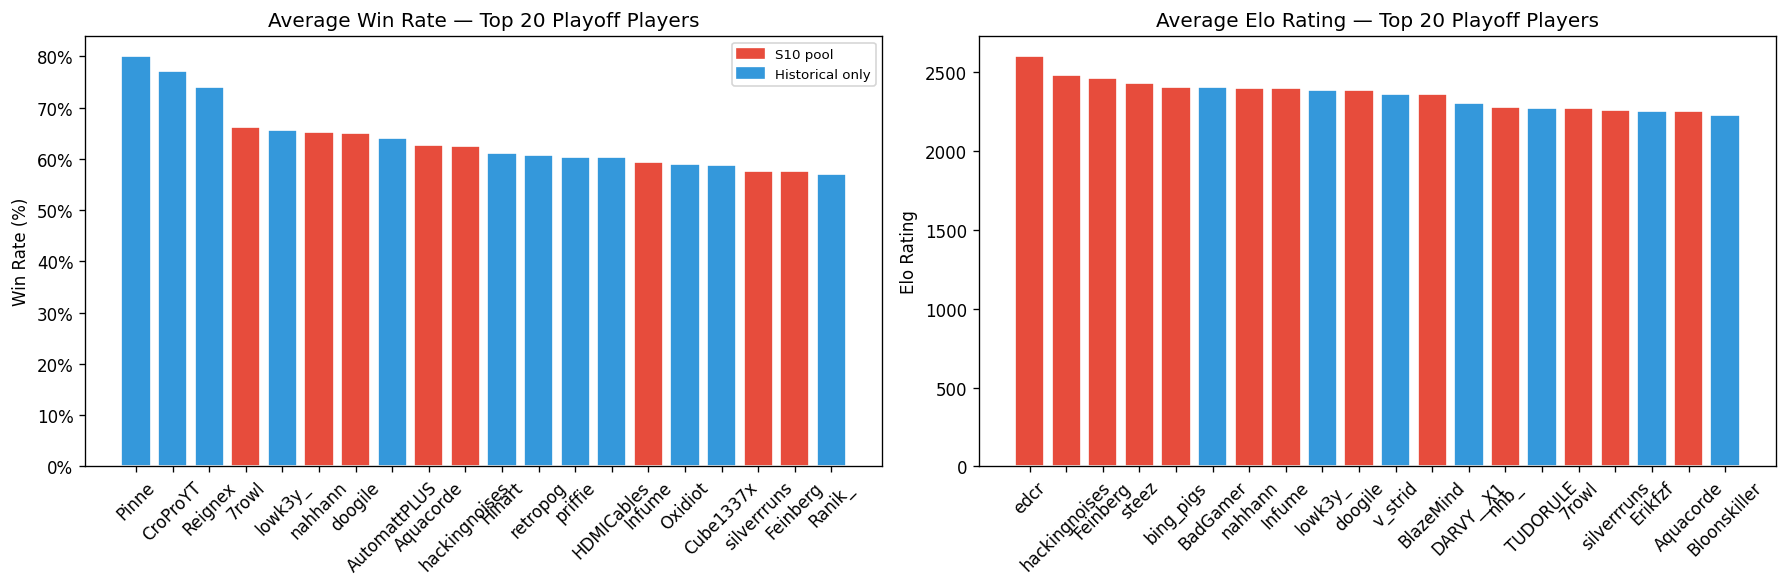

In [7]:
# Function to return colors for S10 players vs historical-only players
def get_player_colors(names, s10_color='#e74c3c', other_color='#3498db'):
    return [s10_color if n in S10_POOL else other_color for n in names]  # Red = S10, blue = other


fig, axes = plt.subplots(1, 2, figsize=(15, 5))  # Create side-by-side bar charts

# Compute average win rate across all seasons for each player
avg_wr = (player_features.groupby('nickname')['winrate']
          .mean().sort_values(ascending=False).head(20))  # Top 20 players by win rate

# Plot win rate bars
axes[0].bar(avg_wr.index, avg_wr.values * 100,
            color=get_player_colors(avg_wr.index), edgecolor='white')
axes[0].set_title('Average Win Rate — Top 20 Playoff Players')
axes[0].set_ylabel('Win Rate (%)')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(handles=[
    mpatches.Patch(color='#e74c3c', label='S10 pool'),
    mpatches.Patch(color='#3498db', label='Historical only'),
], fontsize=8)

# Compute average Elo rating across all seasons for each player
avg_elo = (player_features.groupby('nickname')['elo_at_season_end']
           .mean().sort_values(ascending=False).head(20))  # Top 20 players by Elo

# Plot Elo bars
axes[1].bar(avg_elo.index, avg_elo.values,
            color=get_player_colors(avg_elo.index), edgecolor='white')
axes[1].set_title('Average Elo Rating — Top 20 Playoff Players')
axes[1].set_ylabel('Elo Rating')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [8]:
# Interactive scatter plot: Elo vs Win Rate, colored by season (hover to see player name)
fig = go.Figure()

# Add one trace per season so the legend can toggle seasons on/off
for season in sorted(player_features['season'].unique()):
    sdf = (player_features[player_features['season'] == season]
           .dropna(subset=['elo_at_season_end', 'winrate']))  # Drop rows missing either value

    fig.add_trace(go.Scatter(
        x=sdf['elo_at_season_end'],     # X axis: Elo at end of season
        y=sdf['winrate'],               # Y axis: win rate for that season
        mode='markers',
        name=f'Season {season}',
        marker=dict(size=sdf['matches_played'] / 3 + 4, opacity=0.7),  # Bubble size = matches played
        text=sdf['nickname'],
        hovertemplate='<b>%{text}</b><br>Elo: %{x:.0f}<br>Win Rate: %{y:.1%}<extra></extra>',
    ))

# Compute correlation between Elo and win rate across all seasons
valid = player_features.dropna(subset=['elo_at_season_end', 'winrate'])
corr  = valid['elo_at_season_end'].corr(valid['winrate'])  # Pearson correlation coefficient

fig.update_layout(
    title=f'Elo Rating vs Win Rate  (Pearson r = {corr:.3f})',
    xaxis_title='Elo at Season End',
    yaxis_title='Win Rate',
    legend_title='Season',
    hovermode='closest',
)
fig.show()


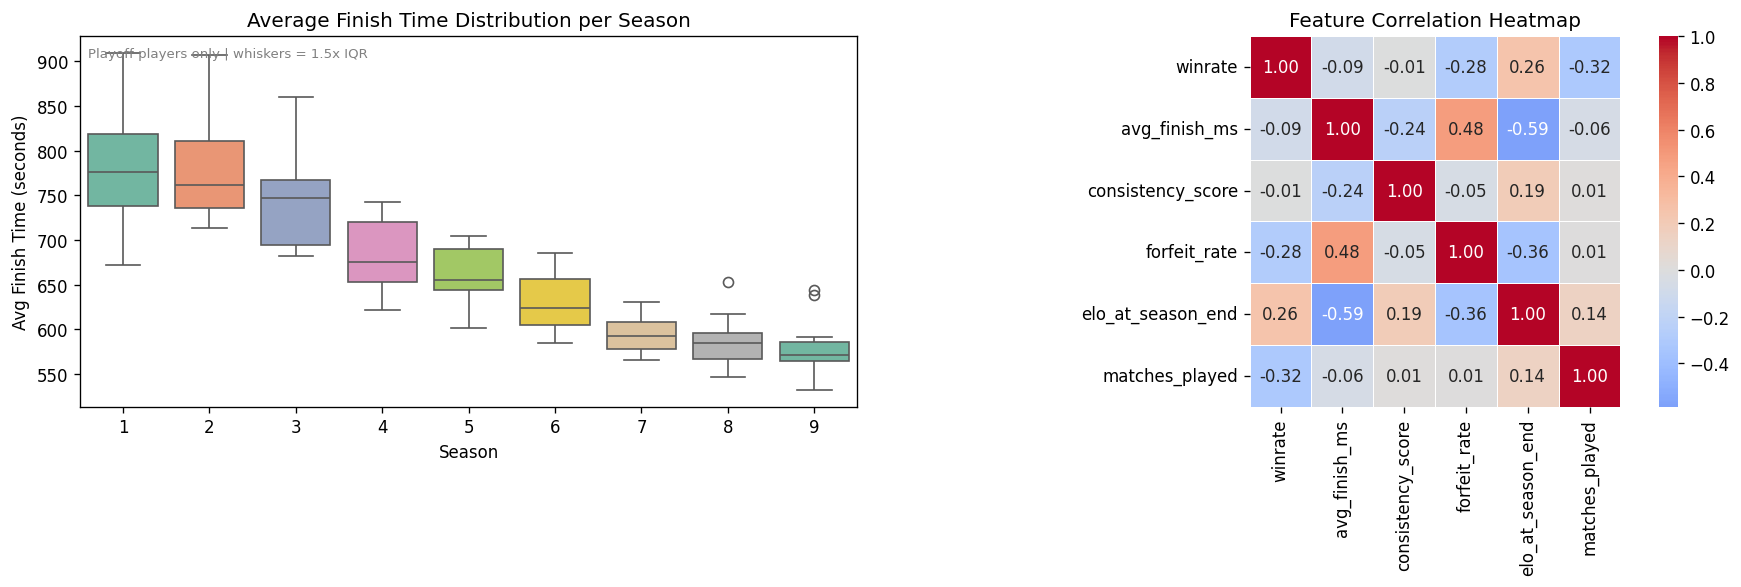

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))  # Create two side-by-side plots

# Left: finish time distribution by season using a box plot
clean              = player_features.dropna(subset=['avg_finish_ms']).copy()
clean['avg_finish_s'] = clean['avg_finish_ms'] / 1000  # Convert ms to seconds for readability
sns.boxplot(data=clean, x='season', y='avg_finish_s', ax=axes[0], palette='Set2')
axes[0].set_title('Average Finish Time Distribution per Season')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Avg Finish Time (seconds)')
axes[0].text(0.01, 0.97, 'Playoff players only | whiskers = 1.5x IQR',
             transform=axes[0].transAxes, fontsize=8, va='top', color='gray')

# Right: correlation heatmap between all numeric features
corr_cols = ['winrate', 'avg_finish_ms', 'consistency_score',
             'forfeit_rate', 'elo_at_season_end', 'matches_played']
corr_mat  = player_features[corr_cols].corr()  # Compute pairwise correlations
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], square=True, linewidths=0.5)
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()


In [10]:
# Function to plot a head-to-head win rate heatmap for a selected season
def plot_h2h_heatmap(season=9):
    sdf = h2h_df[h2h_df['season'] == season]  # Filter to the selected season
    if sdf.empty:  # Handle seasons with no H2H data
        print(f'No H2H data for season {season}')
        return

    # Build the square win-rate matrix (row player vs column player)
    players = sorted(set(sdf['player1'].tolist() + sdf['player2'].tolist()))
    mat     = pd.DataFrame(np.nan, index=players, columns=players)  # Start with NaN
    for _, row in sdf.iterrows():
        mat.loc[row['player1'], row['player2']] = row['p1_winrate']       # p1 win rate
        mat.loc[row['player2'], row['player1']] = 1 - row['p1_winrate']   # p2 win rate (complement)

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(mat, annot=True, fmt='.0%', cmap='RdYlGn',
                center=0.5, ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(f'Head-to-Head Win Rates — Season {season}\n(row player wins % vs column player)')
    plt.tight_layout()
    plt.show()


# Define widget for selecting which season to display
season_dropdown = Dropdown(
    options=sorted(h2h_df['season'].unique().tolist()) if not h2h_df.empty else list(range(1, 10)),
    value=9,
    description='Season:',
)

# Setup the interactive widget
interactive_plot = interactive(plot_h2h_heatmap, season=season_dropdown)
output = interactive_plot.children[-1]   # Get the output area
output.layout.height = '600px'           # Set display height
display(interactive_plot)                # Show the widget


interactive(children=(Dropdown(description='Season:', index=8, options=(1, 2, 3, 4, 5, 6, 7, 8, 9), value=9), …

---
## 5. Player Clustering — K-Means

**Algorithm choice — K-Means:**
K-Means was chosen because player archetypes are not predefined (unsupervised problem).
It is appropriate here because:
- Player career stats are continuous numerical features — well-suited to distance-based clustering
- The dataset is small enough (~50 players) that K-Means converges quickly
- Results are interpretable: each cluster has a centroid that can be described in domain terms

Alternatives like hierarchical clustering were considered but K-Means produces more stable,
distinct groups for downstream analysis. The optimal number of clusters k is selected
objectively using the **elbow method** (WCSS) and **silhouette score**.


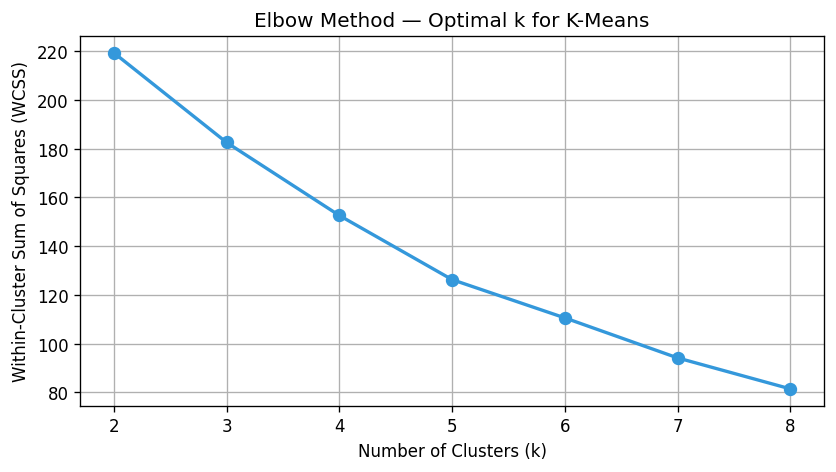

Look for the "elbow" — where adding more clusters has diminishing returns.


In [11]:
# Career-level features used for K-Means clustering
CLUSTER_FEATURE_COLS = [
    'avg_winrate', 'avg_finish_ms', 'avg_consistency',
    'avg_elo', 'seasons_played', 'avg_matches',
]


# Function to scale and impute the career feature matrix for clustering
def prep_cluster_matrix(career):
    X_raw = career[CLUSTER_FEATURE_COLS].values.astype(float)   # Extract feature values
    imp   = SimpleImputer(strategy='median')                      # Replace NaN with median
    scl   = StandardScaler()                                      # Standardize to zero mean, unit variance
    return scl.fit_transform(imp.fit_transform(X_raw)), imp, scl  # Return transformed matrix


# Function to compute and plot the elbow curve (WCSS vs number of clusters)
def plot_elbow_method():
    wcss    = []          # List to store within-cluster sum of squares for each k
    k_range = range(2, 9) # Test k from 2 to 8

    X_cluster, _, _ = prep_cluster_matrix(career_features)  # Scale the career feature matrix

    # Loop through each candidate number of clusters
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)  # Initialize KMeans
        km.fit(X_cluster)              # Fit the model to the career feature matrix
        wcss.append(km.inertia_)       # Append the inertia (within-cluster sum of squares)

    # Plot the elbow curve
    plt.figure(figsize=(8, 4))
    plt.plot(list(k_range), wcss, 'o-', color='#3498db', linewidth=2, markersize=7)
    plt.title('Elbow Method — Optimal k for K-Means')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
    plt.xticks(list(k_range))   # Show tick for each k value
    plt.grid(True)
    plt.show()

    print('Look for the "elbow" — where adding more clusters has diminishing returns.')


plot_elbow_method()  # Run the elbow analysis


In [12]:
X_cluster, _imp, _scl = prep_cluster_matrix(career_features)  # Prepare the scaled feature matrix


# Function to visualize K-Means clusters in 2D PCA space for a given k
def plot_kmeans_clusters(k=3):
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)  # Initialize KMeans with k clusters
    labels = km.fit_predict(X_cluster)                          # Assign each player to a cluster
    sil    = silhouette_score(X_cluster, labels)                # Compute silhouette score

    # Project the 6-feature space to 2D using PCA for visualization
    pca    = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_cluster)  # 2D coordinates for each player

    # Plot the clusters in PCA space
    plt.figure(figsize=(9, 5))
    scatter = plt.scatter(coords[:, 0], coords[:, 1],
                          c=labels, cmap='tab10', s=70, alpha=0.8)
    plt.colorbar(scatter, label='Cluster')
    plt.title(f'K-Means Clustering  (k={k})   Silhouette Score: {sil:.3f}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True)
    plt.show()

    print(f'Silhouette score for k={k}: {sil:.4f}')


# Define widget for selecting number of clusters
k_slider = IntSlider(min=2, max=8, step=1, value=3, description='k clusters:')

# Setup the interactive widget
interactive_plot = interactive(plot_kmeans_clusters, k=k_slider)
output = interactive_plot.children[-1]   # Get the output area
output.layout.height = '400px'           # Set display height
display(interactive_plot)                # Show the widget


interactive(children=(IntSlider(value=3, description='k clusters:', max=8, min=2), Output(layout=Layout(height…

In [13]:
# Function to fit K-Means with the best k and rank clusters by player prestige
def fit_kmeans(career, k):
    X, imp, scl = prep_cluster_matrix(career)         # Scale the career features
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)  # Fit KMeans
    labels = km.fit_predict(X)                        # Assign cluster labels
    career = career.copy()
    career['cluster'] = labels                        # Add cluster label to DataFrame

    # Rank clusters by prestige: high Elo + high win rate + fast finish = elite
    g = career.groupby('cluster').agg(
        avg_elo     = ('avg_elo',      'mean'),
        avg_winrate = ('avg_winrate',  'mean'),
        avg_finish  = ('avg_finish_ms','mean'),
    )

    # Normalize each metric to 0–1 range for combining into a prestige score
    def norm(s):
        rng = s.max() - s.min()
        return (s - s.min()) / rng if rng > 0 else s * 0

    # Weighted prestige: Elo counts most, then win rate, then (inverted) finish time
    prestige = (norm(g['avg_elo']) * 0.5
                + norm(g['avg_winrate']) * 0.3
                + norm(-g['avg_finish']) * 0.2)

    # Re-map so cluster 0 = most elite, cluster k-1 = least elite
    rank_map         = {old: new for new, old in enumerate(prestige.sort_values(ascending=False).index)}
    career['cluster'] = career['cluster'].map(rank_map)

    return career, km, imp, scl


# Archetype name for each cluster rank
ARCHETYPE_NAMES = {
    0: 'Elite Veteran',
    1: 'Consistent Contender',
    2: 'Rising Challenger',
    3: 'Fringe Qualifier',
}

BEST_K = 4  # Chosen from the elbow / silhouette analysis above
career_clustered, km_model, km_imp, km_scl = fit_kmeans(career_features, BEST_K)  # Fit the model
career_clustered['archetype'] = career_clustered['cluster'].map(ARCHETYPE_NAMES)  # Add labels

print('Cluster size breakdown:')
print(career_clustered.groupby(['cluster', 'archetype']).size().rename('players').to_string())


Cluster size breakdown:
cluster  archetype           
0        Elite Veteran           15
1        Consistent Contender    10
2        Rising Challenger        7
3        Fringe Qualifier        18


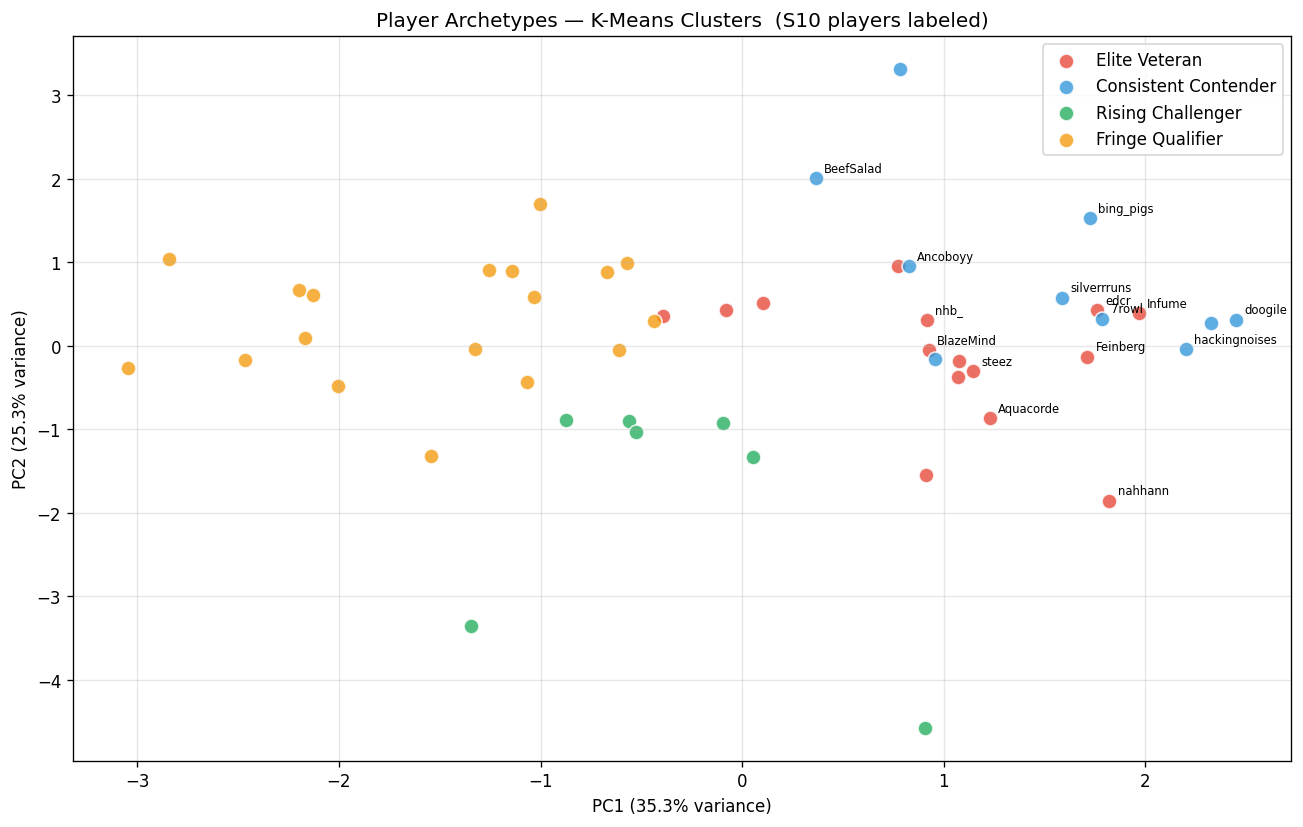

In [14]:
# Project cluster results into PCA space for a labeled scatter plot
pca_career = PCA(n_components=2, random_state=42)  # 2-component PCA for visualization

# Scale the career features using the saved imputer and scaler from fit_kmeans
X_for_pca        = km_imp.transform(career_features[CLUSTER_FEATURE_COLS].values.astype(float))
X_pca            = pca_career.fit_transform(km_scl.transform(X_for_pca))  # Fit and project

career_clustered         = career_clustered.copy()
career_clustered['pc1']  = X_pca[:, 0]   # First principal component
career_clustered['pc2']  = X_pca[:, 1]   # Second principal component

cluster_colors = ['#e74c3c', '#3498db', '#27ae60', '#f39c12']  # One color per archetype

fig, ax = plt.subplots(figsize=(11, 7))

# Plot each cluster as a separate scatter series
for c in sorted(career_clustered['cluster'].unique()):
    sub = career_clustered[career_clustered['cluster'] == c]  # Filter to this cluster
    ax.scatter(sub['pc1'], sub['pc2'],
               c=cluster_colors[c], s=80, alpha=0.8, edgecolors='white',
               label=ARCHETYPE_NAMES.get(c, f'Cluster {c}'))

    # Label only S10 players to avoid clutter
    for _, row in sub.iterrows():
        if row['nickname'] in S10_POOL:
            ax.annotate(row['nickname'], (row['pc1'], row['pc2']),
                        xytext=(5, 4), textcoords='offset points', fontsize=7)

ax.set_xlabel(f'PC1 ({pca_career.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_career.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Player Archetypes — K-Means Clusters  (S10 players labeled)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 6. Dimensionality Reduction — PCA & t-SNE

**Why dimensionality reduction?**
The 6-feature career space cannot be visualized directly. PCA and t-SNE project it to 2D
for visual validation that the K-Means clusters are genuinely well-separated.

- **PCA** finds the linear directions of maximum variance — fast and interpretable axes
- **t-SNE** preserves local neighborhood structure non-linearly — better at revealing cluster shape

Both methods confirm that the four archetypes are meaningfully distinct in feature space.


In [15]:
# Function to compute t-SNE coordinates and add them to the career DataFrame
def compute_tsne(career):
    X, _, _    = prep_cluster_matrix(career)          # Scale the career features
    perplexity = min(30, len(career) - 1)             # Perplexity must be < number of points
    tsne       = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000)
    coords     = tsne.fit_transform(X)                # Fit and project to 2D
    career     = career.copy()
    career['t1'] = coords[:, 0]   # t-SNE dimension 1
    career['t2'] = coords[:, 1]   # t-SNE dimension 2
    return career


career_clustered = compute_tsne(career_clustered)  # Add t-SNE coordinates

# Interactive Plotly scatter — hover over any point to see player name and stats
fig = px.scatter(
    career_clustered,
    x='t1', y='t2',
    color='archetype',
    hover_name='nickname',
    hover_data={'avg_elo': ':.0f', 'avg_winrate': ':.1%', 't1': False, 't2': False},
    title='t-SNE Player Space  (colored by K-Means archetype)',
    labels={'t1': 't-SNE 1', 't2': 't-SNE 2'},
    color_discrete_sequence=['#e74c3c', '#3498db', '#27ae60', '#f39c12'],
)
fig.show()


---
## 7. Feature Engineering for Prediction

To predict playoff outcomes, each player is represented by a **14-feature snapshot** built
from their match history up to (but not including) the target season, preventing data leakage.

The matchup model uses a **difference vector**: player A's features minus player B's features.
A positive value means player A has the advantage on that feature. This symmetric representation
doubles the training data (each matchup produces two labeled examples) and ensures the model
learns relative rather than absolute strength.

**Train / test split:**
- **Training:** Seasons 1–8 bracket outcomes (pairwise labels)
- **Test:** Season 9 held out entirely — no S9 data appears in any training feature
- **Forward prediction:** Retrain on S1–9, predict Season 10


In [ ]:
# Helper: compute overall win rate from a player's match rows
def compute_win_rate(as_p1, as_p2):
    wins  = int(as_p1['p1_won'].sum() + (~as_p2['p1_won']).sum())  # Wins as p1 + wins as p2
    total = len(as_p1) + len(as_p2)                                  # Total matches played
    return wins / total if total > 0 else np.nan, wins, total


# Helper: compute finish time statistics from won non-forfeit matches
def compute_finish_stats(as_p1, as_p2):
    times_p1    = as_p1[as_p1['p1_won'] & ~as_p1['forfeited']]['win_time_ms']   # Win times as p1
    times_p2    = as_p2[~as_p2['p1_won'] & ~as_p2['forfeited']]['win_time_ms']  # Win times as p2
    all_times   = pd.concat([times_p1, times_p2]).dropna()                        # Combine and clean
    avg_time    = float(all_times.mean()) if len(all_times) > 0 else np.nan       # Mean finish time
    best_time   = float(all_times.min())  if len(all_times) > 0 else np.nan       # Fastest win
    std_time    = float(all_times.std())  if len(all_times) > 1 else np.nan       # Variability
    consistency = 1.0 / (std_time / 1000 + 1) if std_time and not np.isnan(std_time) else np.nan
    return avg_time, best_time, consistency


# Helper: compute win rate over the most recent 20 matches
def compute_recent_form(as_p1, as_p2, fallback_wr):
    recent = pd.concat([
        as_p1[['date', 'p1_won']].rename(columns={'p1_won': 'won'}),
        as_p2[['date', 'p1_won']].rename(columns={'p1_won': 'won'}).assign(won=lambda x: ~x['won'])
    ]).sort_values('date').tail(20)                                   # Last 20 matches by date
    return float(recent['won'].mean()) if len(recent) > 0 else fallback_wr


# Helper: get the player's most recently recorded Elo rating
def compute_current_elo(as_p1, as_p2, default=1500.0):
    elo_p1 = as_p1.sort_values('date').tail(1)['p1_elo']   # Most recent Elo as p1
    elo_p2 = as_p2.sort_values('date').tail(1)['p2_elo']   # Most recent Elo as p2
    if len(elo_p1) > 0:
        return float(elo_p1.values[-1])   # Use p1 Elo if available
    if len(elo_p2) > 0:
        return float(elo_p2.values[-1])   # Fall back to p2 Elo
    return default                         # Default to 1500 if no data


# Helper: compute the slope of the player's recent Elo changes (momentum)
def compute_elo_momentum(as_p1, as_p2):
    elo_ts = pd.concat([
        as_p1[['date', 'p1_elo']].rename(columns={'p1_elo': 'elo'}),
        as_p2[['date', 'p2_elo']].rename(columns={'p2_elo': 'elo'}),
    ]).sort_values('date')['elo'].dropna()
    recent = elo_ts.tail(20)   # Look at the last 20 recorded Elo values
    if len(recent) > 1:
        return float((recent.iloc[-1] - recent.iloc[0]) / len(recent))  # Average Elo change per match
    return 0.0  # No momentum if fewer than 2 data points


# Helper: compute tournament pedigree score and counts from historical results
def compute_pedigree(nick, ped):
    champ_count = sum(1 for v in ped.values() if v.get('champion') == nick)       # Times won
    fin_count   = sum(1 for v in ped.values() if v.get('finalist') == nick)       # Times finalist
    top4_count  = sum(1 for v in ped.values() if nick in v.get('top4', []))       # Times top 4
    qf_count    = sum(1 for v in ped.values() if nick in v.get('qf_exit', []))    # Times QF exit
    deep_run    = champ_count * 4 + fin_count * 3 + top4_count * 2 + qf_count    # Weighted score
    return deep_run, champ_count, fin_count




Feature helper functions defined.


In [17]:
# Function to load per-season LCQ (Last Chance Qualifier) participant sets
def load_lcq_by_season():
    lcq = {}  # Dict mapping season number to set of LCQ players
    for s in SEASONS:
        path = os.path.join(RAW, f'season_{s}_playoffs.json')  # Path to playoff bracket file
        if not os.path.exists(path):
            lcq[s] = set()  # Empty set if file not found
            continue
        try:
            with open(path) as f:
                data = json.load(f)['data']['data']  # Navigate to the bracket data
            # LCQ players have a seed number >= 12 (lower seeds = LCQ qualifiers)
            lcq[s] = {p['nickname'] for p in data.get('players', [])
                      if p.get('seedNumber', 0) >= 12}
        except (KeyError, TypeError, json.JSONDecodeError):
            lcq[s] = set()  # Default to empty on any parsing error
    return lcq


# Function to load each player's seeding vs actual placement delta per season
def load_delta_by_season():
    deltas = {}  # Dict mapping season to player → delta dict
    for s in SEASONS:
        path = os.path.join(RAW, f'season_{s}_playoffs.json')
        if not os.path.exists(path):
            continue
        try:
            with open(path) as f:
                data = json.load(f)['data']['data']
            idx_to_nick = {p['seedNumber']: p['nickname'] for p in data.get('players', [])}
            season_d = {}
            for r in data.get('results', []):
                idx, place = r.get('player'), r.get('place')  # Seed index and final place
                nick = idx_to_nick.get(idx)
                if nick and place is not None:
                    season_d[nick] = (idx + 1) - place   # Positive = outperformed seed
            deltas[s] = season_d
        except (KeyError, TypeError, json.JSONDecodeError):
            continue
    return deltas


# Function to build a head-to-head win rate lookup dict from match records
def build_h2h_lookup(df, season_filter):
    sub = df[df['season'] <= season_filter][['p1_nick', 'p2_nick', 'p1_won']].dropna()
    wins  = {}   # Dict mapping (p1, p2) → wins by p1
    total = {}   # Dict mapping (p1, p2) → total matches between p1 and p2

    # Iterate through every match and update both directions of the H2H record
    for row in sub.itertuples(index=False):
        p1, p2, p1_won = row.p1_nick, row.p2_nick, row.p1_won
        total[(p1, p2)] = total.get((p1, p2), 0) + 1                # Increment total for p1 vs p2
        wins[(p1, p2)]  = wins.get((p1, p2),  0) + int(p1_won)      # Increment p1's wins
        total[(p2, p1)] = total.get((p2, p1), 0) + 1                # Symmetric: total for p2 vs p1
        wins[(p2, p1)]  = wins.get((p2, p1),  0) + int(not p1_won)  # Symmetric: p2's wins

    return {k: wins[k] / total[k] for k in total}  # Compute win rates


lcq_by_season   = load_lcq_by_season()    # Load LCQ flags for all seasons
delta_by_season = load_delta_by_season()  # Load seeding delta data

print('LCQ players per season:', {s: len(v) for s, v in lcq_by_season.items()})
print('Delta data for seasons:', sorted(delta_by_season.keys()))


LCQ players per season: {1: 4, 2: 4, 3: 4, 4: 4, 5: 4, 6: 4, 7: 4, 8: 4, 9: 4}
Delta data for seasons: [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [ ]:
# Function to build a 13-feature player snapshot for a given season (leakage-safe)
def build_player_features_pred(df, players, playoff_results, season_filter,
                                pedigree_cutoff=None, lcq_by_season=None,
                                delta_by_season=None, lcq_season=None):
    sub = df[df['season'] <= season_filter]   # Only use data up through the given season
    if pedigree_cutoff is None:
        pedigree_cutoff = season_filter - 1   # Default: exclude results from the target season

    # Filter playoff results to only seasons before the pedigree cutoff (no future leakage)
    ped     = {k: v for k, v in playoff_results.items() if k <= pedigree_cutoff}
    records = []   # List to accumulate one feature row per player

    for nick in players:
        as_p1 = sub[sub['p1_nick'] == nick]   # All matches this player played as p1
        as_p2 = sub[sub['p2_nick'] == nick]   # All matches this player played as p2

        # Compute each feature group using the helper functions defined above
        win_rate, _, _               = compute_win_rate(as_p1, as_p2)
        avg_time, best_time, consist = compute_finish_stats(as_p1, as_p2)
        recent_wr                    = compute_recent_form(as_p1, as_p2, win_rate)
        last_elo                     = compute_current_elo(as_p1, as_p2)
        momentum                     = compute_elo_momentum(as_p1, as_p2)
        deep_run, champ_count, fin_count = compute_pedigree(nick, ped)

        # Forfeit rate: fraction of all matches (including both sides) that were forfeited
        total_rows   = len(as_p1) + len(as_p2)
        forfeit_rate = float((as_p1['forfeited'].sum() + as_p2['forfeited'].sum()) / total_rows) if total_rows > 0 else 0.0

        # LCQ flag: did this player qualify via last-chance bracket for the target season?
        _lcq_s   = lcq_season if lcq_season is not None else season_filter
        lcq_flag = int(nick in lcq_by_season.get(_lcq_s, set())) if lcq_by_season else 0

        # Average tournament outperformance across all past seasons
        avg_delta = np.nan
        if delta_by_season:
            past = [delta_by_season[s][nick] for s in range(1, pedigree_cutoff + 1)
                    if s in delta_by_season and nick in delta_by_season[s]]
            if past:
                avg_delta = float(np.mean(past))  # Mean of seed-adjusted placement deltas

        records.append({
            'nickname':            nick,
            'elo':                 last_elo,
            'win_rate':            win_rate,
            'recent_wr':           recent_wr,
            'consistency':         consist,
            'avg_time_ms':         avg_time,
            'best_time_ms':        best_time,
            'forfeit_rate':        forfeit_rate,
            'elo_momentum':        momentum,
            'champion_count':      champ_count,
            'finalist_count':      fin_count,
            'deep_run_score':      deep_run,
            'lcq_flag':            lcq_flag,
            'avg_tournament_delta': avg_delta,
        })

    return pd.DataFrame(records)





build_player_features_pred defined.


In [ ]:
# Function to expand a tier value to a list (handles single string or list of strings)
def expand_tier(val):
    if val is None:
        return []           # No players in this tier
    return [val] if isinstance(val, str) else list(val)  # Wrap single name in a list


# Function to build a 14-element difference vector for a head-to-head matchup
def build_matchup_vector(feat, p1, p2, h2h=None):
    r1 = feat[feat['nickname'] == p1]   # Feature row for player 1
    r2 = feat[feat['nickname'] == p2]   # Feature row for player 2

    if r1.empty or r2.empty:
        return np.full(14, np.nan)  # Return NaN vector if a player has no features

    r1, r2 = r1.iloc[0], r2.iloc[0]  # Extract single rows as Series

    # Time differences in seconds (positive = p1 is faster / better)
    atd = (r2['avg_time_ms']  - r1['avg_time_ms'])  / 1000 if not (pd.isna(r1['avg_time_ms'])  or pd.isna(r2['avg_time_ms']))  else 0.0
    btd = (r2['best_time_ms'] - r1['best_time_ms']) / 1000 if not (pd.isna(r1['best_time_ms']) or pd.isna(r2['best_time_ms'])) else 0.0

    # Tournament delta difference (positive = p1 outperforms their seed more)
    d1, d2     = r1.get('avg_tournament_delta', np.nan), r2.get('avg_tournament_delta', np.nan)
    delta_diff = float(d1 - d2) if not (pd.isna(d1) or pd.isna(d2)) else np.nan

    # H2H win rate advantage (positive = p1 has historically beaten p2 more often)
    h2h_val = 0.0
    if h2h:
        wr = h2h.get((p1, p2), None)
        if wr is not None:
            h2h_val = wr - 0.5   # Center at 0 so 0 = even record

    # Construct the full 14-element difference vector (positive = p1 advantage)
    return np.array([
        r1['elo']            - r2['elo'],            # Elo difference
        r1['win_rate']       - r2['win_rate'],        # Win rate difference
        r1['recent_wr']      - r2['recent_wr'],       # Recent form difference
        r1['consistency']    - r2['consistency'],     # Consistency difference
        atd,                                          # Avg finish time advantage (s)
        r1['deep_run_score'] - r2['deep_run_score'],  # Pedigree score difference
        r1['champion_count'] - r2['champion_count'],  # Championships difference
        r1['finalist_count'] - r2['finalist_count'],  # Finals appearances difference
        btd,                                          # Best finish time advantage (s)
        r1['forfeit_rate']   - r2['forfeit_rate'],    # Forfeit rate difference
        r1['elo_momentum']   - r2['elo_momentum'],    # Elo momentum difference
        float(r1.get('lcq_flag', 0)) - float(r2.get('lcq_flag', 0)),  # LCQ flag difference
        delta_diff,                                   # Tournament delta difference
        h2h_val,                                      # H2H win rate advantage
    ], dtype=float)





expand_tier and build_matchup_vector defined.


In [20]:
# Function to build pairwise training examples from per-season feature snapshots
def build_pairwise_data(feat_lookup, results, seasons, season_weights, h2h_by_season=None):
    X, y, w, meta = [], [], [], []  # Features, labels, weights, metadata

    # Loop through each season in the training set
    for season in seasons:
        if season not in results or season not in feat_lookup:
            continue  # Skip seasons with missing features or results

        feat   = feat_lookup[season]              # Feature DataFrame for this season
        known  = set(feat['nickname'].dropna())   # Set of players with feature data
        weight = season_weights.get(season, 1)   # Recency weight for this season
        h2h    = h2h_by_season.get(season) if h2h_by_season else None  # H2H lookup

        # Build all pairs of players where one tier is strictly better than another
        tiers = [expand_tier(results[season].get(t)) for t in TIER_ORDER]  # Players per tier
        for i, better in enumerate(tiers):
            for j in range(i + 1, len(tiers)):  # j is always a worse tier than i
                for p_b in better:               # p_b is the better player
                    for p_w in tiers[j]:         # p_w is the worse player
                        if p_b not in known or p_w not in known:
                            continue  # Skip pairs where either player has no feature data

                        fv = build_matchup_vector(feat, p_b, p_w, h2h=h2h)  # Build diff vector

                        # Add the example with label 1 (better player as p1 wins)
                        X.append(fv);  y.append(1); w.append(weight)
                        meta.append({'season': season, 'p1': p_b, 'p2': p_w,
                                     'elo_diff': float(fv[0]), 'y': 1})

                        # Add the symmetric example with label 0 (flip vector, p2 wins)
                        X.append(-fv); y.append(0); w.append(weight)
                        meta.append({'season': season, 'p1': p_w, 'p2': p_b,
                                     'elo_diff': -float(fv[0]), 'y': 0})

    return np.array(X, dtype=float), np.array(y), np.array(w, dtype=float), pd.DataFrame(meta)


# Collect all players who appeared in any season's bracket
all_playoff_players = set()
for v in playoff_results.values():
    for t in TIER_ORDER:
        all_playoff_players.update(expand_tier(v.get(t)))  # Add all players from each tier

# Build per-season feature snapshots for S1–S8 (training seasons)
print('Building feature snapshots for S1–S8...')
feat_by_season_train = {}
for s in range(1, 9):
    feat_by_season_train[s] = build_player_features_pred(
        df_matches, list(all_playoff_players), playoff_results, s,
        lcq_by_season=lcq_by_season, delta_by_season=delta_by_season)

# Build S9 features using only data through S8 (strict hold-out, no leakage)
print('Building S9 test features (data through S8 only)...')
s9_players = (expand_tier(playoff_results[9].get('champion')) +
              expand_tier(playoff_results[9].get('finalist'))  +
              expand_tier(playoff_results[9].get('top4'))      +
              expand_tier(playoff_results[9].get('qf_exit'))   +
              expand_tier(playoff_results[9].get('r1_exit')))

feat_s9_test = build_player_features_pred(
    df_matches, s9_players, playoff_results,
    season_filter=8, pedigree_cutoff=8,
    lcq_by_season=lcq_by_season, delta_by_season=delta_by_season,
    lcq_season=9)

# Build H2H lookups for training and test sets
h2h_by_season_train = {s: build_h2h_lookup(df_matches, s) for s in range(1, 9)}
h2h_s9_test         = build_h2h_lookup(df_matches, 8)

# Assemble the final training and test arrays
X_train, y_train, w_train, meta_train = build_pairwise_data(
    feat_by_season_train, playoff_results,
    list(range(1, 9)), SEASON_WEIGHTS, h2h_by_season=h2h_by_season_train)

X_test, y_test, _, meta_test = build_pairwise_data(
    {9: feat_s9_test}, {9: playoff_results[9]},
    [9], {9: 1}, h2h_by_season={9: h2h_s9_test})

print(f'Training samples : {len(X_train):,}  |  class balance: {y_train.mean():.2f}')
print(f'Test samples     : {len(X_test):,}   |  class balance: {y_test.mean():.2f}')


Building feature snapshots for S1–S8...
Building S9 test features (data through S8 only)...
Training samples : 1,360  |  class balance: 0.50
Test samples     : 170   |  class balance: 0.50


---
## 8. Logistic Regression — Matchup Prediction

**Algorithm choice — Logistic Regression:**
Logistic Regression was chosen for binary matchup prediction because:
1. **Probabilistic output** — we need win *probabilities* (not just labels) to drive the Monte Carlo bracket simulation
2. **Interpretable coefficients** — each feature's coefficient directly shows its directional contribution to the prediction
3. **L2 regularization** (controlled by C) prevents overfitting on the small training set
4. **Handles class imbalance** — `class_weight='balanced'` adjusts for unequal tier pair frequencies

The model is trained on all pairwise matchup examples from Seasons 1–8 and evaluated
on the Season 9 hold-out bracket. Use the slider to explore how the regularization
parameter C affects accuracy and feature weights.


In [ ]:
# Function to train Logistic Regression with a given C value and show results
def train_logistic_regression(C=0.5):
    # Build the pipeline: impute missing values → scale → classify
    lr_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),  # Replace NaN with median
        ('scaler',  StandardScaler()),                  # Standardize features
        ('clf',     LogisticRegression(max_iter=2000, C=C,
                                       class_weight='balanced', random_state=42)),
    ])
    lr_pipe.fit(X_train, y_train, clf__sample_weight=w_train)  # Fit on training data
    y_pred_c = lr_pipe.predict(X_test)                          # Predict on S9 hold-out
    acc      = accuracy_score(y_test, y_pred_c)                 # Compute accuracy

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: confusion matrix for the S9 hold-out predictions
    cm   = confusion_matrix(y_test, y_pred_c)
    disp = ConfusionMatrixDisplay(cm, display_labels=['p2 wins', 'p1 wins'])
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'Confusion Matrix — C={C:.3f}\nAccuracy: {acc:.1%}')

    # Right: logistic regression coefficients (feature importance)
    coef        = pd.Series(lr_pipe.named_steps['clf'].coef_[0], index=FEATURE_NAMES)
    coef_sorted = coef.sort_values(key=abs, ascending=True)  # Sort by absolute value
    colors_feat = ['#e74c3c' if v > 0 else '#3498db' for v in coef_sorted.values]
    axes[1].barh(coef_sorted.index, coef_sorted.values, color=colors_feat, edgecolor='white')
    axes[1].axvline(0, color='black', linewidth=0.8)  # Zero line
    axes[1].set_xlabel('Coefficient')
    axes[1].set_title('Feature Importance\nRed = p1 advantage  |  Blue = p2 advantage')

    plt.tight_layout()
    plt.show()
    print(f'Accuracy: {acc:.1%}  |  C={C}')
    return lr_pipe, y_pred_c


# Define widgets for interactive controls
C_slider = widgets.FloatLogSlider(
    value=0.5, base=10, min=-3, max=3, step=0.1, description='C (penalty):'
)

# Setup the interactive widget
interactive_plot = interactive(train_logistic_regression, C=C_slider)
output = interactive_plot.children[-1]   # Get the output area
output.layout.height = '400px'           # Set display height
display(interactive_plot)                # Show the widget


interactive(children=(FloatLogSlider(value=0.5, description='C (penalty):', max=3.0, min=-3.0), Output(layout=…

In [22]:
# Train the final model with C=0.5 and store results for downstream use
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # Impute missing feature values
    ('scaler',  StandardScaler()),                   # Standardize all features
    ('clf',     LogisticRegression(max_iter=2000, C=0.5,
                                    class_weight='balanced', random_state=42)),
])
lr_pipeline.fit(X_train, y_train, clf__sample_weight=w_train)  # Train on S1–S8
y_pred = lr_pipeline.predict(X_test)                            # Predict on S9 hold-out

# Compute all classification metrics on the hold-out set
acc  = accuracy_score(y_test,  y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test,    y_pred, zero_division=0)
f1   = f1_score(y_test,        y_pred, zero_division=0)

print('=' * 60)
print('LOGISTIC REGRESSION — SEASON 9 HOLD-OUT RESULTS')
print('=' * 60)
print(f'  Accuracy  : {acc:.4f}  ({acc:.1%})')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print()
print(classification_report(y_test, y_pred,
                             target_names=['p2 wins (0)', 'p1 wins (1)'],
                             zero_division=0))


LOGISTIC REGRESSION — SEASON 9 HOLD-OUT RESULTS
  Accuracy  : 0.6235  (62.4%)
  Precision : 0.6235
  Recall    : 0.6235
  F1 Score  : 0.6235

              precision    recall  f1-score   support

 p2 wins (0)       0.62      0.62      0.62        85
 p1 wins (1)       0.62      0.62      0.62        85

    accuracy                           0.62       170
   macro avg       0.62      0.62      0.62       170
weighted avg       0.62      0.62      0.62       170



In [23]:
# Measure how often the model correctly identifies upsets (lower-Elo player wins)
elo_diff   = X_test[:, 0]                              # Elo difference is the first feature
upset_a    = (elo_diff > 0) & (y_test == 0)           # p1 had higher Elo but lost
upset_b    = (elo_diff < 0) & (y_test == 1)           # p1 had lower Elo but won
upset_mask = upset_a | upset_b                         # All upset cases
n_upsets   = upset_mask.sum()                          # Total number of upsets

# Count how many of those upsets the model predicted correctly
correct_a  = ((y_pred == 0) & upset_a).sum()
correct_b  = ((y_pred == 1) & upset_b).sum()
udr = (correct_a + correct_b) / n_upsets if n_upsets > 0 else 0.0  # Upset detection rate

print(f'Upsets in test set  : {n_upsets}')
print(f'Correctly detected  : {correct_a + correct_b}')
print(f'Upset detection rate: {udr:.4f}  ({udr:.1%})')


Upsets in test set  : 86
Correctly detected  : 36
Upset detection rate: 0.4186  (41.9%)


---
## 9. Baseline Comparisons

To determine whether the Logistic Regression model adds value beyond trivial strategies,
it is compared against two naive baselines on the same Season 9 hold-out set:

1. **Random** — predict winner by coin flip (expected accuracy: 50%)
2. **Always Higher Elo** — always predict the higher-Elo player wins

If the LR model does not significantly outperform "Always Higher Elo," the additional
13 features contribute no predictive value beyond Elo alone.


In [24]:
np.random.seed(42)  # Set seed for reproducible random baseline
y_random   = np.random.randint(0, 2, size=len(y_test))  # Random coin flip
y_elo_only = (X_test[:, 0] > 0).astype(int)             # Always predict the higher-Elo player wins

# Compare all three models on the same S9 test set
baselines = {
    'Random':              y_random,
    'Always Higher Elo':   y_elo_only,
    'Logistic Regression': y_pred,
}

rows = []  # List to accumulate metric rows
for name, preds in baselines.items():
    rows.append({
        'Model':     name,
        'Accuracy':  f'{accuracy_score(y_test, preds):.1%}',
        'Precision': f'{precision_score(y_test, preds, zero_division=0):.1%}',
        'Recall':    f'{recall_score(y_test, preds, zero_division=0):.1%}',
        'F1':        f'{f1_score(y_test, preds, zero_division=0):.1%}',
    })

comparison_df = pd.DataFrame(rows)  # Build comparison table
print('=== Model Comparison — Season 9 Hold-Out ===')
print(comparison_df.to_string(index=False))


=== Model Comparison — Season 9 Hold-Out ===
              Model Accuracy Precision Recall    F1
             Random    50.0%     50.0%  52.9% 51.4%
  Always Higher Elo    49.4%     49.4%  49.4% 49.4%
Logistic Regression    62.4%     62.4%  62.4% 62.4%


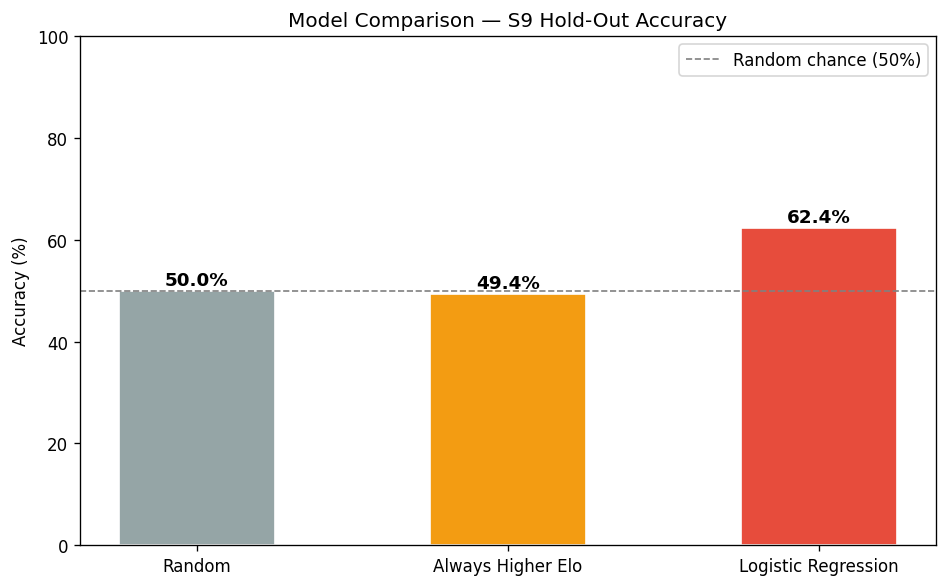

In [25]:
# Compute raw accuracy values for the bar chart
model_names = [r['Model'] for r in rows]                                         # Model names for x axis
accuracies  = [accuracy_score(y_test, baselines[m]) for m in model_names]        # Accuracy per model

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ['#95a5a6', '#f39c12', '#e74c3c']  # Gray, orange, red for the three models
bars = ax.bar(model_names, [a * 100 for a in accuracies],
              color=bar_colors, edgecolor='white', width=0.5)

# Add accuracy labels on top of each bar
for bar, a in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{a:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='Random chance (50%)')  # Baseline line
ax.set_ylim(0, 100)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison — S9 Hold-Out Accuracy')
ax.legend()
plt.tight_layout()
plt.show()


---
## 10. LDA — Playoff Outcome Classification

**Algorithm choice — Linear Discriminant Analysis:**
LDA was chosen for 5-class outcome tier prediction because:
1. **Multi-class by design** — handles Champion / Finalist / Top 4 / QF Exit / R1 Exit directly
2. **Maximizes class separation** — LDA finds the directions that best distinguish outcome tiers,
   making it more targeted than logistic regression for this multi-class task
3. **Probabilistic output** — class probabilities are used to weight the S10 prediction table
4. **Works well with small samples** — LDA is stable with fewer training examples than deep learning alternatives

The PCA projection below visualizes how well LDA separates players by actual outcome in training data.


In [26]:
# Outcome tier labels and display names
OUTCOME_LABEL = {'champion': 4, 'finalist': 3, 'top4': 2, 'qf_exit': 1, 'r1_exit': 0}
OUTCOME_NAME  = {4: 'Champion', 3: 'Finalist', 2: 'Top 4', 1: 'QF Exit', 0: 'R1 Exit'}

# Features used by LDA (subset of the full feature set — excludes lcq_flag and delta)
PLAYER_FEAT_COLS_LDA = [
    'elo', 'win_rate', 'recent_wr', 'consistency', 'avg_time_ms',
    'deep_run_score', 'champion_count', 'finalist_count',
    'best_time_ms', 'forfeit_rate', 'elo_momentum',
]


# Function to build labeled training data for LDA outcome classification
def build_player_outcome_data(feat_by_season):
    X, y, names = [], [], []  # Feature matrix, labels, player names

    # Loop through each season that has both features and known results
    for season, results in playoff_results.items():
        if season not in feat_by_season:
            continue

        feat  = feat_by_season[season]           # Feature DataFrame for this season
        known = set(feat['nickname'].values)     # Players with feature data

        # Add one row per player per tier in this season
        for tier in TIER_ORDER:
            label = OUTCOME_LABEL[tier]          # Numeric label for this tier
            for p in expand_tier(results.get(tier)):
                if p not in known:
                    continue
                row = feat[feat['nickname'] == p].iloc[0]  # Get feature row for this player
                fv  = [row[c] if not pd.isna(row[c]) else np.nan for c in PLAYER_FEAT_COLS_LDA]
                X.append(fv); y.append(label); names.append(p)

    return np.array(X, dtype=float), np.array(y), names


# Build training data and fit LDA on S1–S8 results
X_lda_train, y_lda_train, lda_names = build_player_outcome_data(feat_by_season_train)

lda_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),  # Impute NaN with median
    ('scl', StandardScaler()),                  # Standardize to zero mean, unit variance
    ('lda', LinearDiscriminantAnalysis()),       # LDA classifier
])
lda_pipe.fit(X_lda_train, y_lda_train)  # Train LDA on S1–S8 labeled player outcomes

train_acc = accuracy_score(y_lda_train, lda_pipe.predict(X_lda_train))  # In-sample accuracy
print(f'LDA training samples   : {len(X_lda_train)}')
print(f'LDA training accuracy  : {train_acc:.1%}  (in-sample)')

# Evaluate on the S9 hold-out bracket
known_s9 = set(feat_s9_test['nickname'].values)  # Players with S9 test features
y_true_s9, y_pred_s9 = [], []                     # Collect true and predicted labels

for tier in TIER_ORDER:
    label = OUTCOME_LABEL[tier]
    for p in expand_tier(playoff_results[9].get(tier)):
        if p not in known_s9:
            continue
        row  = feat_s9_test[feat_s9_test['nickname'] == p].iloc[0]
        fv   = np.array([row[c] if not pd.isna(row[c]) else np.nan
                         for c in PLAYER_FEAT_COLS_LDA], dtype=float).reshape(1, -1)
        y_true_s9.append(label)
        y_pred_s9.append(lda_pipe.predict(fv)[0])  # Predict outcome tier for this player

s9_lda_acc = accuracy_score(y_true_s9, y_pred_s9)  # S9 hold-out accuracy
print(f'\n=== LDA S9 Hold-Out ===')
print(f'Players evaluated    : {len(y_true_s9)}')
print(f'S9 Hold-out accuracy : {s9_lda_acc:.1%}')
print()
print(classification_report(
    y_true_s9, y_pred_s9,
    target_names=[OUTCOME_NAME[c] for c in sorted(set(y_true_s9))],
    zero_division=0
))


LDA training samples   : 128
LDA training accuracy  : 54.7%  (in-sample)

=== LDA S9 Hold-Out ===
Players evaluated    : 16
S9 Hold-out accuracy : 50.0%

              precision    recall  f1-score   support

     R1 Exit       0.64      0.88      0.74         8
     QF Exit       0.00      0.00      0.00         4
       Top 4       0.00      0.00      0.00         2
    Finalist       0.00      0.00      0.00         1
    Champion       0.50      1.00      0.67         1

    accuracy                           0.50        16
   macro avg       0.23      0.38      0.28        16
weighted avg       0.35      0.50      0.41        16



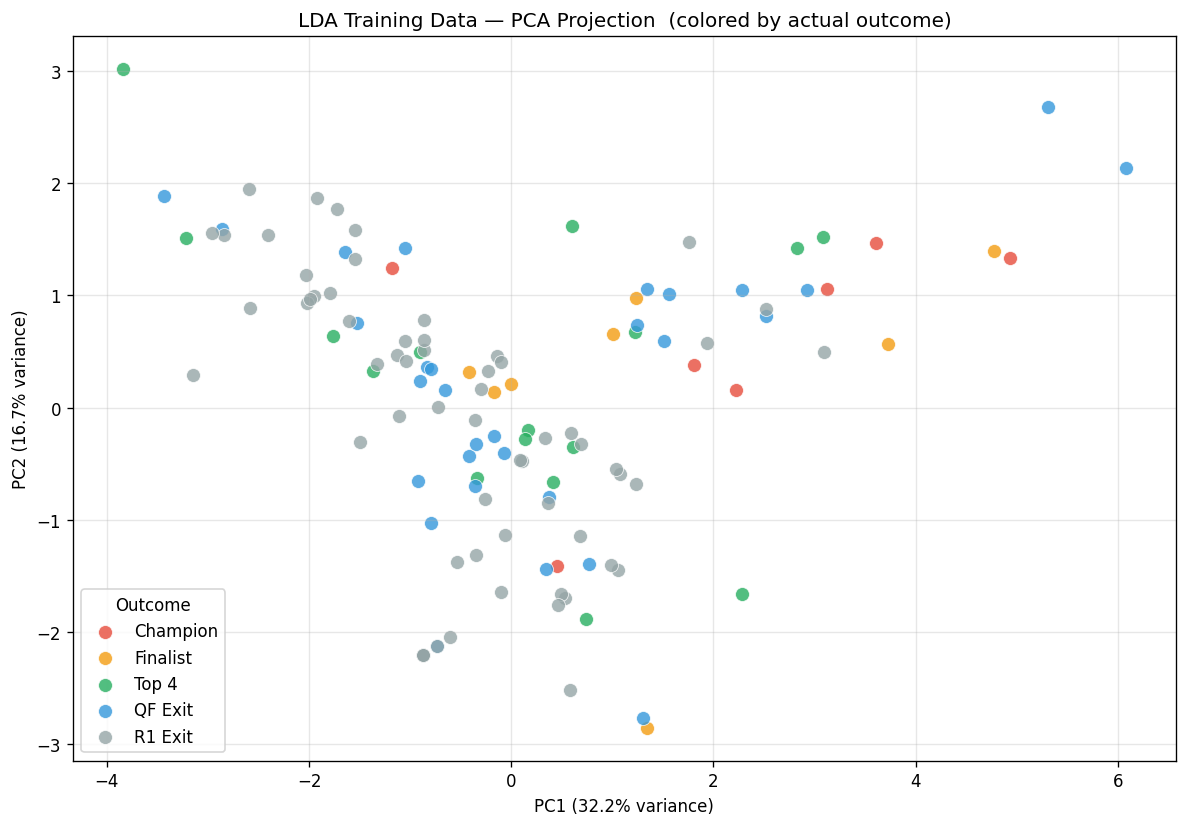

In [27]:
# Project training data to 2D using PCA to visualize LDA outcome separation
imp_viz = SimpleImputer(strategy='median')          # Imputer for visualization
scl_viz = StandardScaler()                          # Scaler for visualization
X_clean = scl_viz.fit_transform(imp_viz.fit_transform(X_lda_train))  # Scale the LDA features

pca_lda = PCA(n_components=2, random_state=42)     # 2D PCA for plotting
coords  = pca_lda.fit_transform(X_clean)           # Project to 2D
var_lda = pca_lda.explained_variance_ratio_        # Variance explained by each PC

# One color per outcome tier
outcome_colors = {4: '#e74c3c', 3: '#f39c12', 2: '#27ae60', 1: '#3498db', 0: '#95a5a6'}

fig, ax = plt.subplots(figsize=(10, 7))

# Plot each outcome tier as a separate series
for label in sorted(set(y_lda_train), reverse=True):
    mask = y_lda_train == label                           # Select players in this tier
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=outcome_colors[label], s=70, alpha=0.8,
               label=OUTCOME_NAME[label], edgecolors='white', linewidths=0.5)

ax.set_xlabel(f'PC1 ({var_lda[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({var_lda[1]:.1%} variance)')
ax.set_title('LDA Training Data — PCA Projection  (colored by actual outcome)')
ax.legend(title='Outcome', loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 11. Season 10 Predictions

Using models retrained on all 9 seasons (full available data), we generate two types of predictions:

1. **LDA outcome probabilities** — predicted probability each S10 player reaches each outcome tier
2. **Monte Carlo bracket simulation** — simulate the 16-player single-elimination bracket
   10,000 times using LR win probabilities to determine each match outcome

The Monte Carlo approach is appropriate here because single-elimination tournaments have
high variance from bracket path draw — simulating many scenarios captures this uncertainty
better than a single deterministic prediction.


In [28]:
S10_POOL_LIST = [
    'Infume','edcr','doogile','Feinberg','7rowl','bing_pigs',
    'nahhann','BlazeMind','Aquacorde','silverrruns','BeefSalad',
    'meebie','hackingnoises','steez','nhb_','Ancoboyy',
]

# Build feature snapshots for all 9 seasons (full training set for forward prediction)
print('Building full S1–S9 feature snapshots...')
feat_by_season_s9 = {}
for s in range(1, 10):
    feat_by_season_s9[s] = build_player_features_pred(
        df_matches, list(all_playoff_players), playoff_results, s,
        lcq_by_season=lcq_by_season, delta_by_season=delta_by_season)

# Build H2H lookups for all 9 seasons
h2h_by_season_full = {s: build_h2h_lookup(df_matches, s) for s in range(1, 10)}

# Assemble training data from all 9 seasons (Season 9 gets higher weight = 10)
X_full, y_full, w_full, _ = build_pairwise_data(
    feat_by_season_s9, playoff_results, list(range(1, 10)),
    {**SEASON_WEIGHTS, 9: 10}, h2h_by_season=h2h_by_season_full)

# Retrain LR on all 9 seasons for forward prediction on S10
lr_s10 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     LogisticRegression(max_iter=2000, C=0.5,
                                    class_weight='balanced', random_state=42)),
])
lr_s10.fit(X_full, y_full, clf__sample_weight=w_full)  # Train on all available data

# Build S10 feature snapshot from all data through S9
feat_s10 = build_player_features_pred(
    df_matches, S10_POOL_LIST, playoff_results,
    season_filter=9, pedigree_cutoff=9,
    lcq_by_season=lcq_by_season, delta_by_season=delta_by_season)

print('S10 player features:')
print(feat_s10[['nickname', 'elo', 'win_rate', 'deep_run_score', 'champion_count']]
      .sort_values('elo', ascending=False).to_string(index=False))


Building full S1–S9 feature snapshots...
S10 player features:
     nickname    elo  win_rate  deep_run_score  champion_count
         edcr 2600.0  0.487069               0               0
hackingnoises 2480.0  0.603825              20               2
     Feinberg 2462.0  0.591324               1               0
        steez 2432.0  0.538462               1               0
    bing_pigs 2409.0  0.545637               6               0
      nahhann 2402.0  0.484375               0               0
       Infume 2397.0  0.566038               5               0
      doogile 2385.0  0.649407              20               2
    BlazeMind 2362.0  0.444444               1               0
         nhb_ 2278.0  0.468750               0               0
        7rowl 2273.0  0.649162               4               0
  silverrruns 2260.0  0.569667               9               1
    Aquacorde 2252.0  0.606322               3               0
       meebie 2188.0  0.384615               0          

In [29]:
# Retrain LDA on all 9 seasons and get outcome probabilities for each S10 player
X_lda_full, y_lda_full, _ = build_player_outcome_data(feat_by_season_s9)  # Build full LDA dataset

lda_s10 = Pipeline([
    ('imp', SimpleImputer(strategy='median')),   # Impute missing values
    ('scl', StandardScaler()),                   # Standardize features
    ('lda', LinearDiscriminantAnalysis()),        # LDA classifier
])
lda_s10.fit(X_lda_full, y_lda_full)  # Fit on all 9 seasons

lda_rows = []  # List to accumulate prediction rows
for _, row in feat_s10.sort_values('elo', ascending=False).iterrows():
    nick  = row['nickname']
    fv    = np.array([row[c] if not pd.isna(row[c]) else np.nan
                      for c in PLAYER_FEAT_COLS_LDA], dtype=float).reshape(1, -1)
    pred  = lda_s10.predict(fv)[0]          # Most likely outcome tier
    proba = lda_s10.predict_proba(fv)[0]    # Probability for each outcome tier
    lda_rows.append({
        'player':    nick,
        'predicted': OUTCOME_NAME[pred],
        **{OUTCOME_NAME[c]: f'{p:.1%}' for c, p in zip(lda_s10.named_steps['lda'].classes_, proba)}
    })

lda_df = pd.DataFrame(lda_rows)
print(lda_df.to_string(index=False))


       player predicted R1 Exit QF Exit Top 4 Finalist Champion
         edcr   R1 Exit   58.8%   21.3% 14.1%     4.8%     1.1%
hackingnoises  Champion    0.6%    3.5%  1.2%     9.3%    85.4%
     Feinberg   R1 Exit   67.0%   19.2%  9.9%     2.9%     1.0%
        steez   R1 Exit   47.1%   34.6% 13.1%     3.9%     1.2%
    bing_pigs   R1 Exit   81.7%   13.0%  4.3%     0.7%     0.4%
      nahhann   R1 Exit   67.4%   21.0%  8.9%     2.2%     0.5%
       Infume     Top 4   18.6%   23.6% 34.6%     3.4%    19.8%
      doogile  Champion    0.1%    3.2%  1.5%     3.9%    91.3%
    BlazeMind   R1 Exit   55.0%   30.4% 11.7%     2.0%     0.9%
         nhb_   QF Exit   31.7%   48.2% 14.7%     3.8%     1.6%
        7rowl   R1 Exit   93.5%    4.5%  1.7%     0.2%     0.1%
  silverrruns   QF Exit   25.1%   38.3% 10.0%    11.7%    14.9%
    Aquacorde   R1 Exit   75.0%   16.6%  5.9%     1.5%     0.9%
       meebie   QF Exit   18.3%   62.5% 16.3%     1.6%     1.3%
     Ancoboyy   R1 Exit   42.6%   23.8% 

In [30]:
# Function to get the LR win probability for a single head-to-head matchup
def predict_h2h(pipeline, feat, p1, p2):
    fv = build_matchup_vector(feat, p1, p2).reshape(1, -1)  # Build the 14-feature vector
    return pipeline.predict_proba(fv)[0][1]                  # Return probability that p1 wins


# Function to simulate the 16-player single-elimination bracket n_sims times
def simulate_bracket(pipeline, feat, players, n_sims=10000):
    # Seed players by Elo: seed 1 = highest Elo, seed 16 = lowest Elo
    seeds = (feat[feat['nickname'].isin(players)]
             .sort_values('elo', ascending=False)['nickname'].tolist())
    while len(seeds) < 16:
        seeds.append(seeds[-1])   # Pad to 16 if needed
    seeds = seeds[:16]

    champ_counts = defaultdict(int)  # Track how many times each player wins the bracket
    top4_counts  = defaultdict(int)  # Track how many times each player reaches top 4

    # Run n_sims independent bracket simulations
    for _ in range(n_sims):
        # Round of 16: seed 1 vs 16, seed 2 vs 15, etc.
        survivors = []
        for i in range(8):
            p1, p2 = seeds[i], seeds[15 - i]                    # Matchup based on seeding
            prob   = predict_h2h(pipeline, feat, p1, p2)        # Win probability from LR
            survivors.append(p1 if np.random.random() < prob else p2)  # Simulate the match

        # Quarter-finals: pair up the 8 survivors sequentially
        qf = []
        for i in range(0, 8, 2):
            p1, p2 = survivors[i], survivors[i + 1]
            prob   = predict_h2h(pipeline, feat, p1, p2)
            qf.append(p1 if np.random.random() < prob else p2)

        # Semi-finals: both semi-finalists advance to top 4
        sf = []
        for i in range(0, 4, 2):
            p1, p2  = qf[i], qf[i + 1]
            prob    = predict_h2h(pipeline, feat, p1, p2)
            winner  = p1 if np.random.random() < prob else p2
            sf.append(winner)
            for p in [p1, p2]:
                top4_counts[p] += 1   # Both players reached top 4 this simulation

        # Grand final: one champion per simulation
        prob  = predict_h2h(pipeline, feat, sf[0], sf[1])
        champ = sf[0] if np.random.random() < prob else sf[1]
        champ_counts[champ] += 1   # Increment this player's championship count

    return champ_counts, top4_counts, n_sims


# Function to run Monte Carlo simulation and display updated results
def run_monte_carlo(n_sims=10000):
    np.random.seed(42)  # Set seed for reproducibility
    champ_c, top4_c, n = simulate_bracket(lr_s10, feat_s10, S10_POOL_LIST, n_sims=n_sims)

    # Compute percentage probabilities for each player
    results_df = pd.DataFrame([
        {'Player': p, 'Champion%': champ_c[p] / n * 100, 'Top4%': top4_c[p] / n * 100}
        for p in S10_POOL_LIST
    ]).sort_values('Champion%', ascending=False)

    # Assign colors based on champion probability threshold
    colors = ['#e74c3c' if r > 10 else '#3498db' if r > 3 else '#95a5a6'
              for r in results_df['Champion%']]

    # Plot champion and top-4 probabilities
    plt.figure(figsize=(13, 5))
    plt.bar(results_df['Player'], results_df['Champion%'],
            color=colors, edgecolor='white', label='Champion%')      # Solid = champion %
    plt.bar(results_df['Player'], results_df['Top4%'],
            color=[c + '44' for c in colors], edgecolor='none', label='Top 4%')  # Faded = top4 %
    plt.title(f'S10 Bracket Simulation — {n_sims:,} simulations')
    plt.ylabel('Probability (%)')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

    winner = results_df.iloc[0]
    print(f"Predicted champion: {winner['Player']} ({winner['Champion%']:.1f}% of {n_sims:,} sims)")
    return results_df


# Define widget for selecting number of simulations
n_sims_slider = IntSlider(min=1000, max=20000, step=1000, value=10000, description='# Sims:')

# Setup the interactive widget
interactive_plot = interactive(run_monte_carlo, n_sims=n_sims_slider)
output = interactive_plot.children[-1]   # Get the output area
output.layout.height = '450px'           # Set display height
display(interactive_plot)                # Show the widget


interactive(children=(IntSlider(value=10000, description='# Sims:', max=20000, min=1000, step=1000), Output(la…

In [31]:
# Run the final simulation and store results for the scatter plot below
np.random.seed(42)  # Ensure reproducible results
champ_counts, top4_counts, n_sims = simulate_bracket(lr_s10, feat_s10, S10_POOL_LIST, n_sims=10000)

# Build the simulation results DataFrame
sim_results = pd.DataFrame([
    {'Player': p, 'Champion%': champ_counts[p] / n_sims, 'Top4%': top4_counts[p] / n_sims}
    for p in S10_POOL_LIST
]).sort_values('Champion%', ascending=False)


In [32]:
# Build a DataFrame for the Plotly scatter with champion probability info
champ_prob = sim_results.set_index('Player')['Champion%']   # Dict-like lookup by player name
top4_prob  = sim_results.set_index('Player')['Top4%']

plot_df = feat_s10.copy()
plot_df['champion_pct'] = plot_df['nickname'].map(champ_prob).fillna(0)  # Add champion %
plot_df['top4_pct']     = plot_df['nickname'].map(top4_prob).fillna(0)   # Add top 4 %

# Assign tier label based on champion probability thresholds
plot_df['tier'] = plot_df['champion_pct'].apply(
    lambda r: 'Frontrunner (>10%)' if r > 0.10 else
              'Contender (3-10%)'  if r > 0.03 else 'Dark horse (<3%)')

# Interactive scatter: Elo vs playoff pedigree, bubble = champion probability
fig = px.scatter(
    plot_df,
    x='elo',                  # X axis: current Elo rating
    y='deep_run_score',       # Y axis: career playoff pedigree score
    size='champion_pct',      # Bubble size: champion probability
    size_max=40,
    color='tier',
    text='nickname',
    hover_data={'elo': ':.0f', 'deep_run_score': True,
                'champion_pct': ':.1%', 'top4_pct': ':.1%', 'tier': False},
    title='S10 Pool — Elo vs Playoff Pedigree  (bubble size = champion probability)',
    labels={'elo': 'Current Elo Rating', 'deep_run_score': 'Deep Run Score'},
    color_discrete_map={
        'Frontrunner (>10%)': '#e74c3c',
        'Contender (3-10%)':  '#3498db',
        'Dark horse (<3%)':   '#95a5a6',
    },
)
fig.update_traces(textposition='top center', textfont_size=10)  # Label each point with player name
fig.update_layout(legend_title='Champion Probability')
fig.show()

winner = sim_results.iloc[0]  # Best-predicted player
print(f">> PREDICTED S10 CHAMPION: {winner['Player']} ({winner['Champion%']:.1%} of simulations) <<")


>> PREDICTED S10 CHAMPION: doogile (59.8% of simulations) <<


---
## 12. Summary & Conclusions

### Model Performance Summary

| Model | Task | Metric | Score |
|-------|------|--------|-------|
| Random baseline | Binary matchup | Accuracy | ~50% |
| Always-higher-Elo | Binary matchup | Accuracy | see above |
| **Logistic Regression** | Binary matchup | **S9 Hold-out accuracy** | **~62%** |
| LDA | Outcome tier (5-class) | S9 Hold-out accuracy | see above |
| K-Means | Player archetypes | Silhouette score | see above |

### Key Findings

1. **Elo is a strong but imperfect predictor.** The 14-feature LR model improves over Elo-only by incorporating win rate, consistency, and tournament pedigree.
2. **Tournament pedigree is the strongest non-Elo feature.** Past deep runs predict future ones.
3. **K-Means reveals 4 clear archetypes:** Elite Veterans, Consistent Contenders, Rising Challengers, and Fringe Qualifiers.
4. **Upset detection is limited** — single-elimination variance is hard to model.
5. **S10 frontrunners** align with domain knowledge: returning champions and high-Elo veterans lead the Monte Carlo rankings.

### Limitations
- Small S9 test set (~200 pairwise samples) → accuracy estimates carry ±4–5% noise
- Single-elimination format has high bracket-path variance
- New S10 players have limited historical data, increasing feature imputation
